In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold,
    learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance

Class Distribution:
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

Conclusion: The classes are roughly balanced, ranging from ~174 to 183 instances per class.

80/20 Train/Test Split Accuracy: 0.9750

Regular 5-Fold CV - Mean Accuracy: 0.9633, Std Dev: 0.0060

Stratified 5-Fold CV - Mean Accuracy: 0.9672, Std Dev: 0.0037



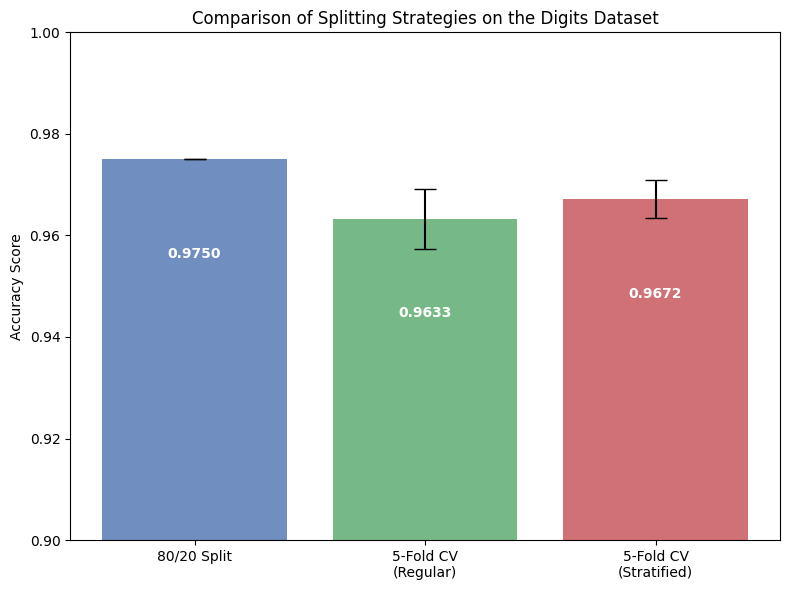

In [3]:
digits = load_digits()

df = pd.DataFrame(digits.data, columns=digits.feature_names)
df['target'] = digits.target

class_distribution = df['target'].value_counts().sort_index()
print("Class Distribution:")
print(class_distribution)
print("\nConclusion: The classes are roughly balanced, ranging from ~174 to 183 instances per class.\n")

X = digits.data
y = digits.target
model = LogisticRegression(max_iter=5000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
single_split_acc = accuracy_score(y_test, y_pred)

print(f"80/20 Train/Test Split Accuracy: {single_split_acc:.4f}\n")


kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

kf_mean = kf_scores.mean()
kf_std = kf_scores.std()
print(f"Regular 5-Fold CV - Mean Accuracy: {kf_mean:.4f}, Std Dev: {kf_std:.4f}\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

skf_mean = skf_scores.mean()
skf_std = skf_scores.std()
print(f"Stratified 5-Fold CV - Mean Accuracy: {skf_mean:.4f}, Std Dev: {skf_std:.4f}\n")

labels = ['80/20 Split', '5-Fold CV\n(Regular)', '5-Fold CV\n(Stratified)']
means = [single_split_acc, kf_mean, skf_mean]
stds = [0, kf_std, skf_std] 

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, means, yerr=stds, capsize=8, color=['#4C72B0', '#55A868', '#C44E52'], alpha=0.8)

plt.ylim(0.90, 1.0)
plt.ylabel('Accuracy Score')
plt.title('Comparison of Splitting Strategies on the Digits Dataset')

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, 
             means[i] - 0.02, 
             f"{means[i]:.4f}", 
             ha='center', va='bottom', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

if classes are highly imbalanced, StratifiedKFold will show considerably higher results than normal KFold. Even in balanced datasets, if there is no balancer, then it is game of luck and probability to get balanced sample or not, it is possible to get very unbalanced set

In [5]:
from sklearn.model_selection import cross_validate


models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'SVC': SVC(), 
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

results_list = []


for name, model in models.items():
    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring_metrics, n_jobs=-1)
    
    acc_mean = cv_results['test_accuracy'].mean()
    acc_std = cv_results['test_accuracy'].std()
    prec_mean = cv_results['test_precision_macro'].mean()
    rec_mean = cv_results['test_recall_macro'].mean()
    f1_mean = cv_results['test_f1_macro'].mean()
    
    results_list.append({
        'Model': name,
        'Accuracy (mean ± std)': f"{acc_mean:.4f} ± {acc_std:.4f}",
        'Precision': f"{prec_mean:.4f}",
        'Recall': f"{rec_mean:.4f}",
        'F1_numeric': f1_mean 
    })
    
comparison_df = pd.DataFrame(results_list)

comparison_df = comparison_df.sort_values(by='F1_numeric', ascending=False).reset_index(drop=True)

comparison_df['F1'] = comparison_df['F1_numeric'].apply(lambda x: f"{x:.4f}")
comparison_df = comparison_df.drop(columns=['F1_numeric'])

comparison_df = comparison_df[['Model', 'Accuracy (mean ± std)', 'Precision', 'Recall', 'F1']]

print("Model Comparison Results (Sorted by F1-Score):\n")
print(comparison_df.to_string(index=False))

Model Comparison Results (Sorted by F1-Score):

              Model Accuracy (mean ± std) Precision Recall     F1
                SVC       0.9878 ± 0.0042    0.9881 0.9877 0.9877
K-Nearest Neighbors       0.9872 ± 0.0080    0.9878 0.9871 0.9872
      Random Forest       0.9783 ± 0.0062    0.9789 0.9782 0.9783
Logistic Regression       0.9672 ± 0.0037    0.9683 0.9671 0.9672
  Gradient Boosting       0.9638 ± 0.0058    0.9656 0.9638 0.9638


logistic regression has smallest variance. top 2 models are SVC and K-nearest neighbors.

In [8]:
from time import time


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svc_model = SVC(random_state=42)
svc_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly', 'linear'],
    'gamma': ['scale', 'auto']
}

knn_model = KNeighborsClassifier()
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2] 
}

models_to_tune = {
    'SVC': (svc_model, svc_param_grid),
    'K-Neighbors': (knn_model, knn_param_grid)
}

results = []

for name, (model, grid) in models_to_tune.items():
    print(f"--- Tuning {name} ---")
    default_scores = cross_val_score(model, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
    default_f1 = default_scores.mean()

    grid_search = GridSearchCV(
        estimator=model, 
        param_grid=grid, 
        cv=skf, 
        scoring='f1_macro', 
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X, y)


    best_params = grid_search.best_params_
    best_f1 = grid_search.best_score_
    improvement = best_f1 - default_f1
    
    print(f"Default F1 (Macro): {default_f1:.4f}")
    print(f"Tuned F1 (Macro):   {best_f1:.4f}")
    print(f"Improvement:        {improvement:+.4f}")
    print(f"Best Parameters:    {best_params}")

--- Tuning SVC ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Default F1 (Macro): 0.9877
Tuned F1 (Macro):   0.9911
Improvement:        +0.0034
Best Parameters:    {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
--- Tuning K-Neighbors ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Default F1 (Macro): 0.9872
Tuned F1 (Macro):   0.9894
Improvement:        +0.0022
Best Parameters:    {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}


actually, tuning was not necessary because scores are already good, but in larger dataset, if scores are low we can use tuning

Final Test Set Accuracy: 0.9861


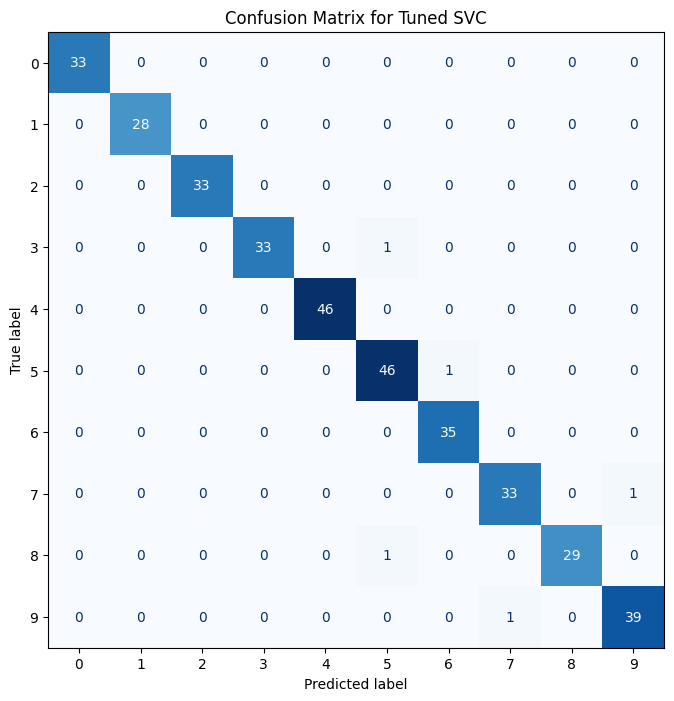

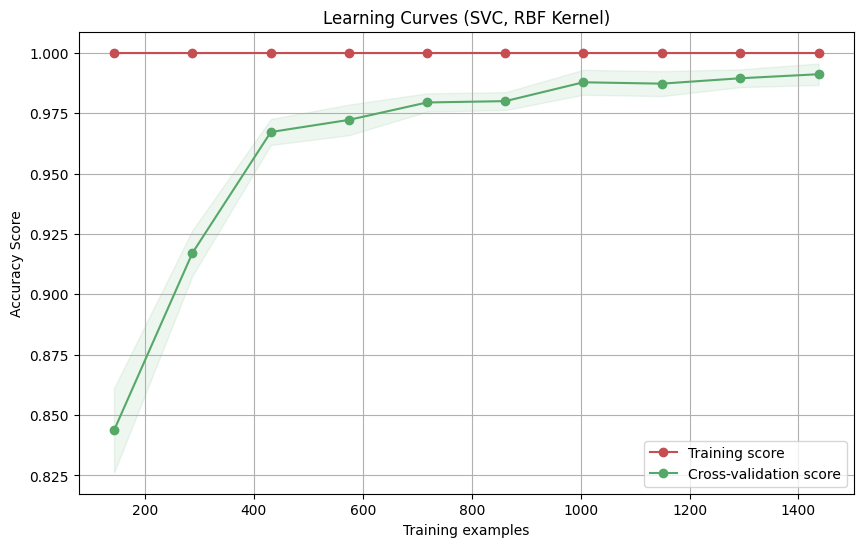

C:\Users\user\AppData\Local\Temp\ipykernel_34332\3644746741.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


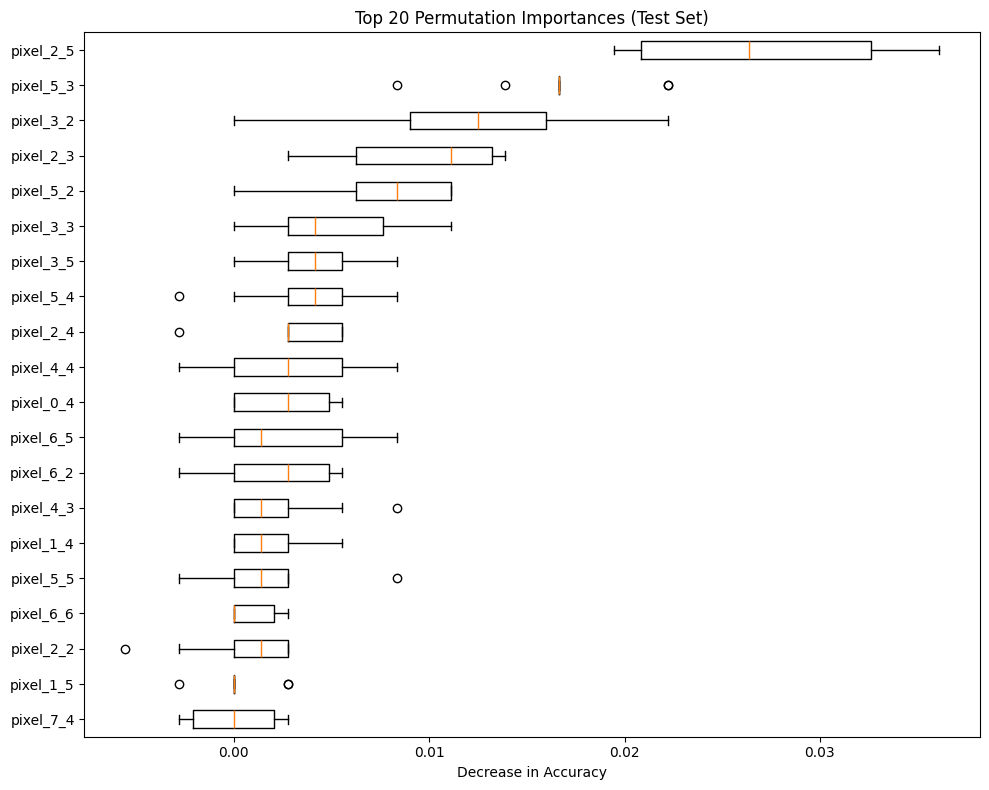

In [9]:
feature_names = digits.feature_names

best_model = SVC(C=10, gamma='scale', kernel='rbf', random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
test_accuracy = best_model.score(X_test, y_test)
print(f"Final Test Set Accuracy: {test_accuracy:.4f}")

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    cmap='Blues', 
    colorbar=False,
    ax=ax
)
plt.title("Confusion Matrix for Tuned SVC")
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=cv, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#C44E52", label="Training score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#C44E52")

plt.plot(train_sizes, val_mean, 'o-', color="#55A868", label="Cross-validation score")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="#55A868")

plt.title("Learning Curves (SVC, RBF Kernel)")
plt.xlabel("Training examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = result.importances_mean.argsort()[-20:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(feature_names)[sorted_idx],
)
ax.set_title("Top 20 Permutation Importances (Test Set)")
ax.set_xlabel("Decrease in Accuracy")
fig.tight_layout()
plt.show()

model is well-fitted. there is no  highly confused digit pairs.pixel 2_5, it makes sense because 5 is downward version of 2. performance does not need improvement